In [35]:
%matplotlib widget

In [36]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [37]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [38]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

In [39]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 50.74305555555554, 'wavelenght')

In [40]:
z = 0.01505 
l_HA_z = 6563 * (1+z)
l_HB_z = 4861 * (1+z) 
l_NII_z = 6583 * (1+z)
l_SII_z = 6717 * (1+z)
l_OIII_z = 5007 * (1+z)

l_HA = 6654
l_HB = 4929
l_NII_2 = 6676
l_NII_1 = 6641
l_SII_1 = 6811
l_SII_2 = 6825
l_OIII_1 = 5029
l_OIII_2 = 5077

#seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/PSF/Real_seeing_Mrk553.txt")
#sigma = seeing[0] / 2.35

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

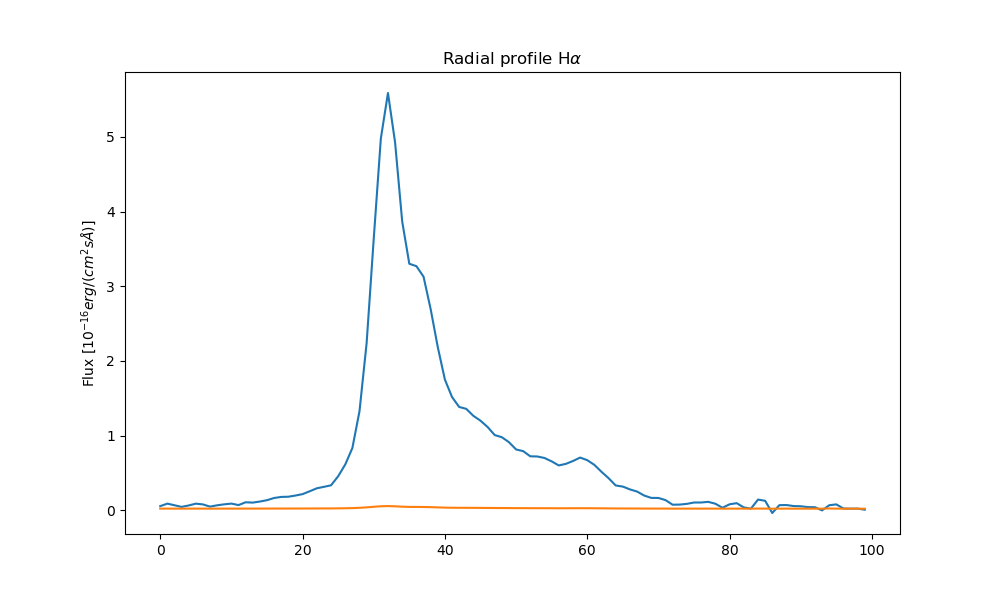

In [41]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10408\3519671148.py:30: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,6))


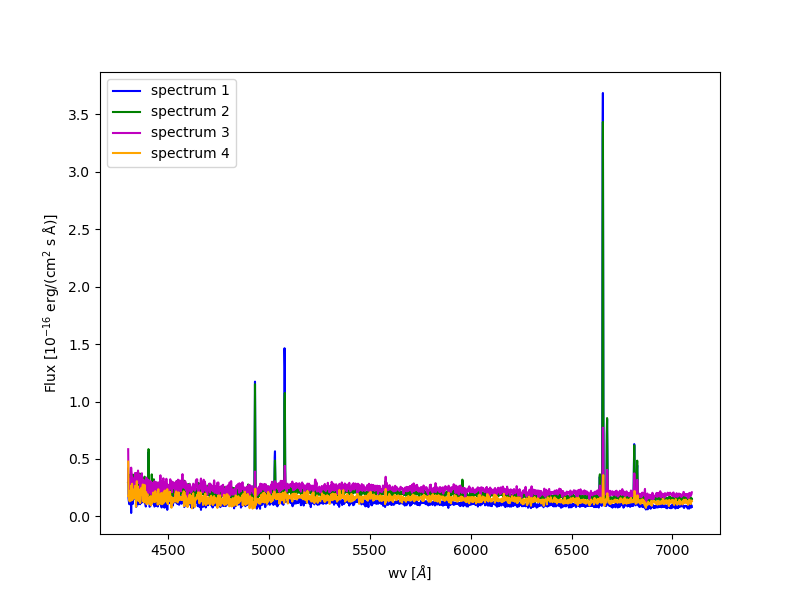

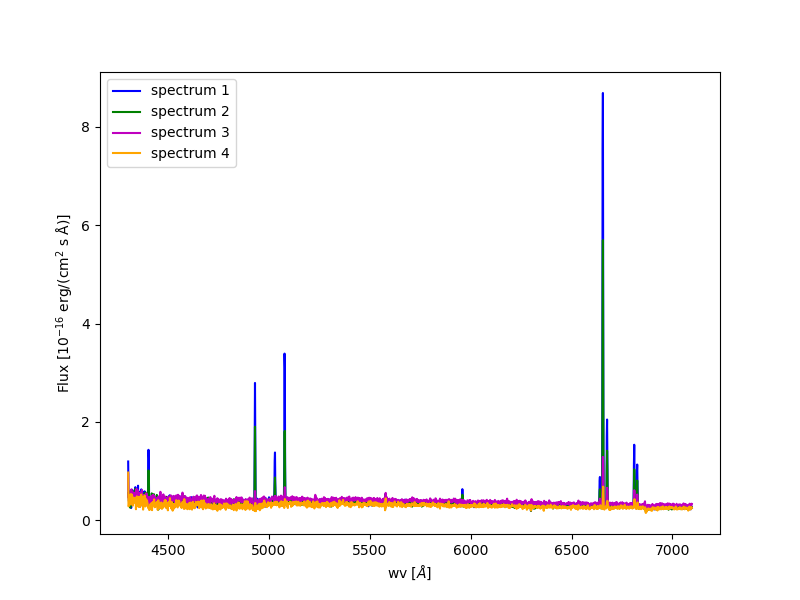

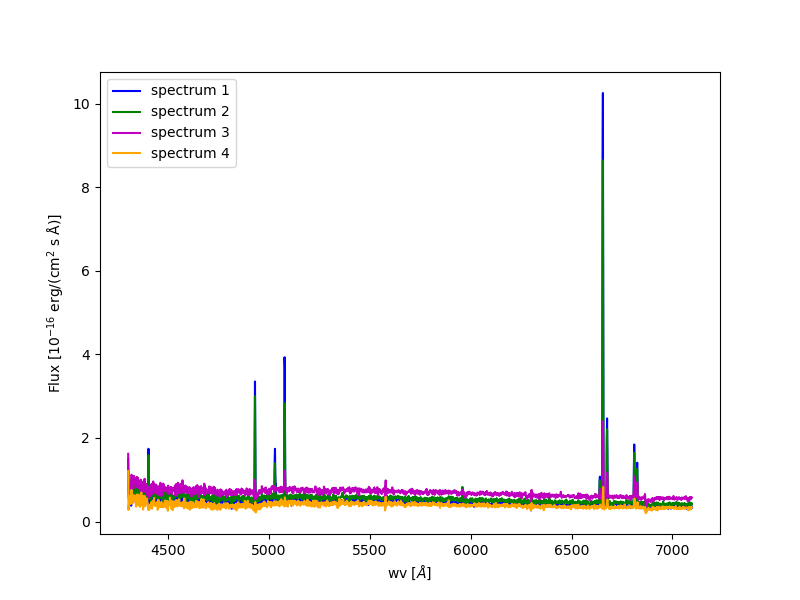

In [42]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Fit/4_peaks/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = 3.174 #in pixels
sigma = seeing/2.35
peaks = fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green', 'm', 'orange']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

In [43]:
peaks

array([31.6212, 36.2909, 45.    , 59.6844])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [44]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6000)*(wv < 6500)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    4.621064    6.679949    6.842376    4.939715
Continuum_2    8.297705   10.381512   11.464083    8.854806
Continuum_3    7.920303    9.958136   10.864174    8.107509

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.128824    0.217378    0.251560    0.149356
Continuum_2    0.122788    0.209971    0.245797    0.161697
Continuum_3    0.105878    0.181270    0.214429    0.141885

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.027878    0.032542    0.036765    0.030236
Continuum_2    0.014798    0.020225    0.021441    0.018261
Continuum_3    0.013368    0.018203    0.019737    0.017500

DataFrame Combinato:
                   SNR                                      Signal             \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_4 Spectrum_1 Spectrum_2   
Continuum_1   4.621064   6.679949   6.842376

In [45]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    7.312433    8.108525    8.958492    6.443166
Continuum_2   11.550379   12.229124   13.438637   11.224441
Continuum_3   11.685812   11.766629   13.596246   11.209346

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.374652    0.360991    0.419769    0.299706
Continuum_2    0.364945    0.350499    0.408772    0.321543
Continuum_3    0.312968    0.302801    0.358753    0.280118

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.051235    0.044520    0.046857    0.046515
Continuum_2    0.031596    0.028661    0.030418    0.028647
Continuum_3    0.026782    0.025734    0.026386    0.024990

DataFrame Combinato:
                   SNR                                      Signal             \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_4 Spectrum_1 Spectrum_2   
Continuum_1   7.312433   8.108525   8.958492

In [46]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    7.825855    9.321936   10.534086    7.031754
Continuum_2   12.658093   13.987778   16.124979   12.181437
Continuum_3   12.304608   13.608270   16.610751   12.291374

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.484863    0.582120    0.747459    0.395480
Continuum_2    0.478952    0.564135    0.727984    0.425886
Continuum_3    0.410064    0.488520    0.639961    0.372027

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.061957    0.062446    0.070956    0.056242
Continuum_2    0.037838    0.040331    0.045146    0.034962
Continuum_3    0.033326    0.035899    0.038527    0.030267

DataFrame Combinato:
                   SNR                                      Signal             \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_4 Spectrum_1 Spectrum_2   
Continuum_1   7.825855   9.321936  10.534086

## Redshift

In [47]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate (regione centrale): 11
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4401.37999999997   emission                50
4929.739999999814   emission               407
5028.899999999785   emission               474
5076.259999999771   emission               506
5958.339999999511   emission              1102
 6640.61999999931   emission              1563
6655.419999999305   emission              1573
6676.139999999299   emission              1587
6810.819999999259   emission              1678
6825.619999999255   emission              1688
6868.539999999242 absorption              1717
Numero di righe trovate (regione centrale): 11
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4401.37999999997   emission                50
4929.739999999814   emission               407
5028.89999999

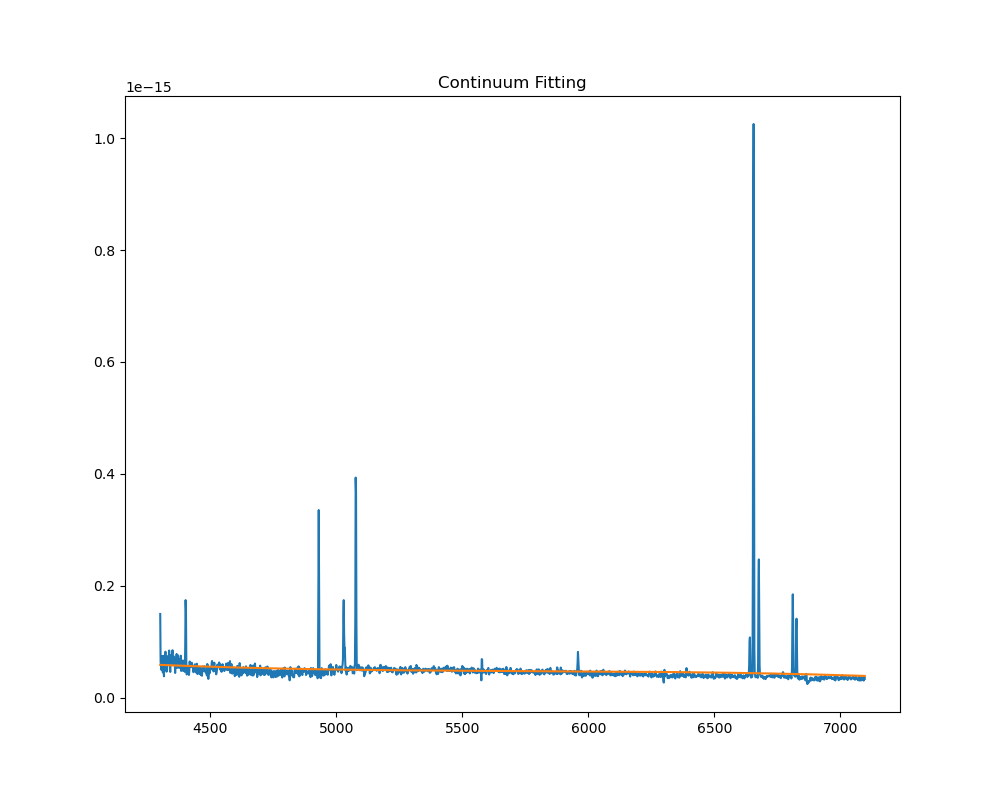

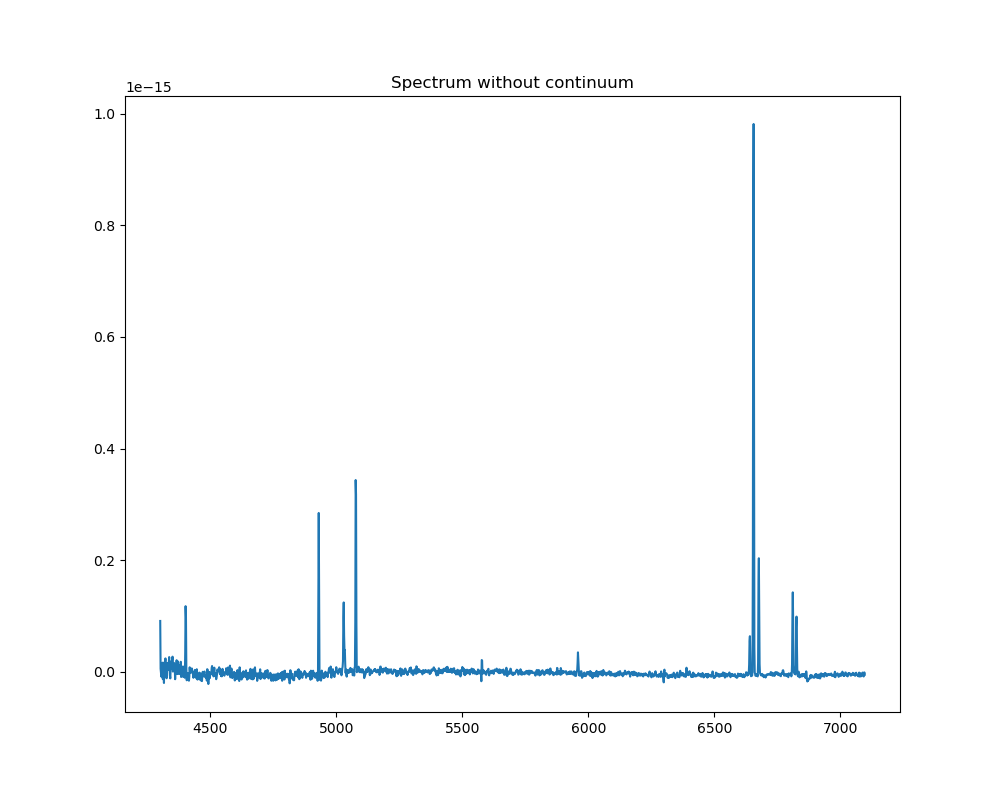

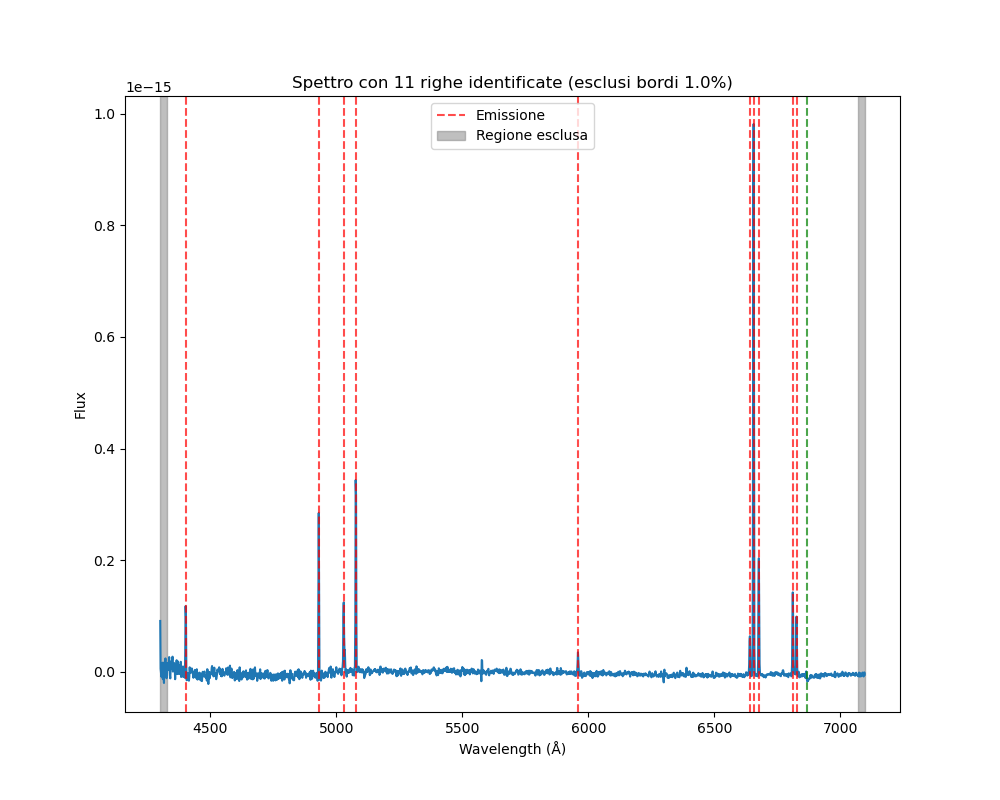

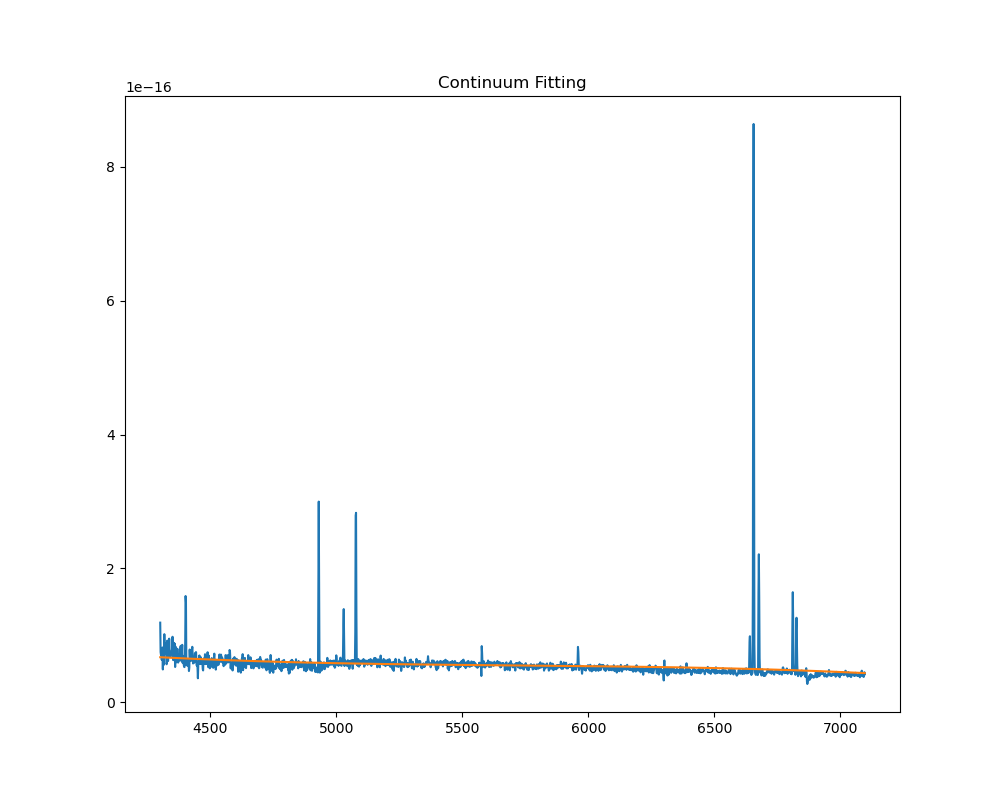

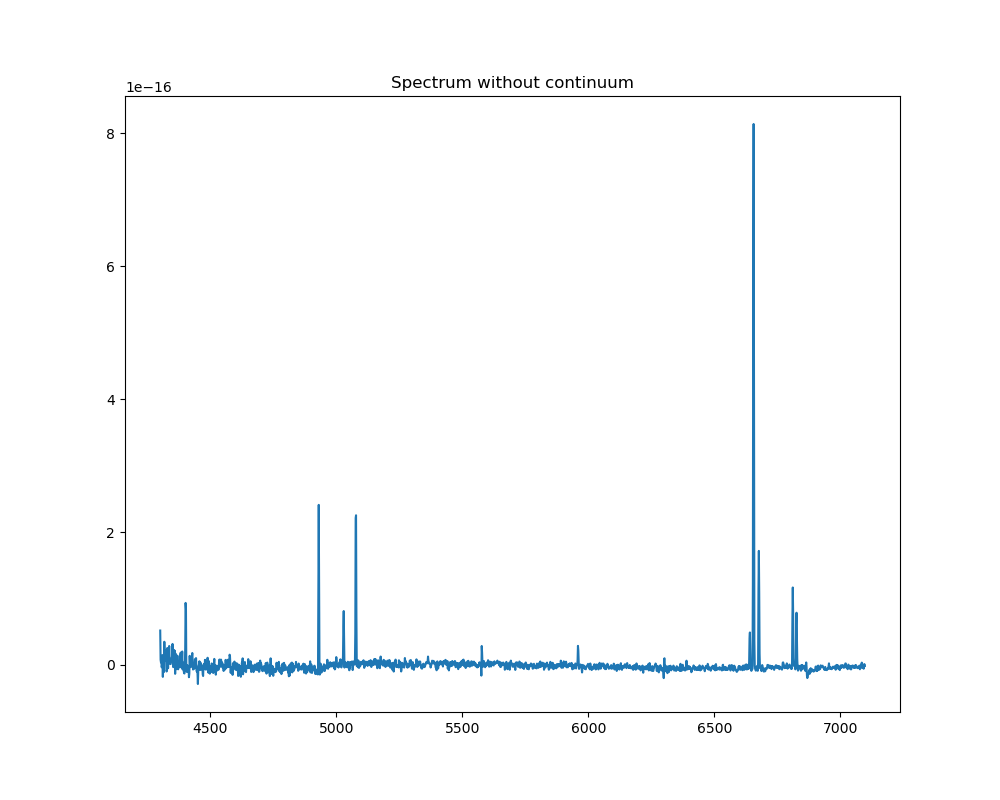

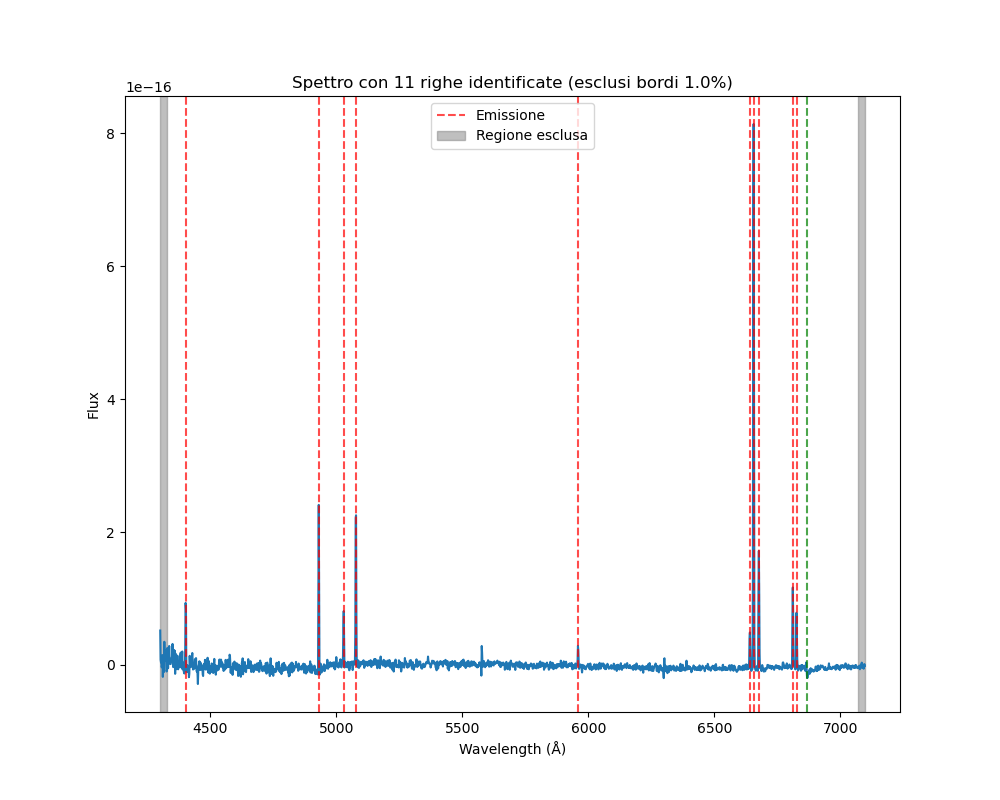

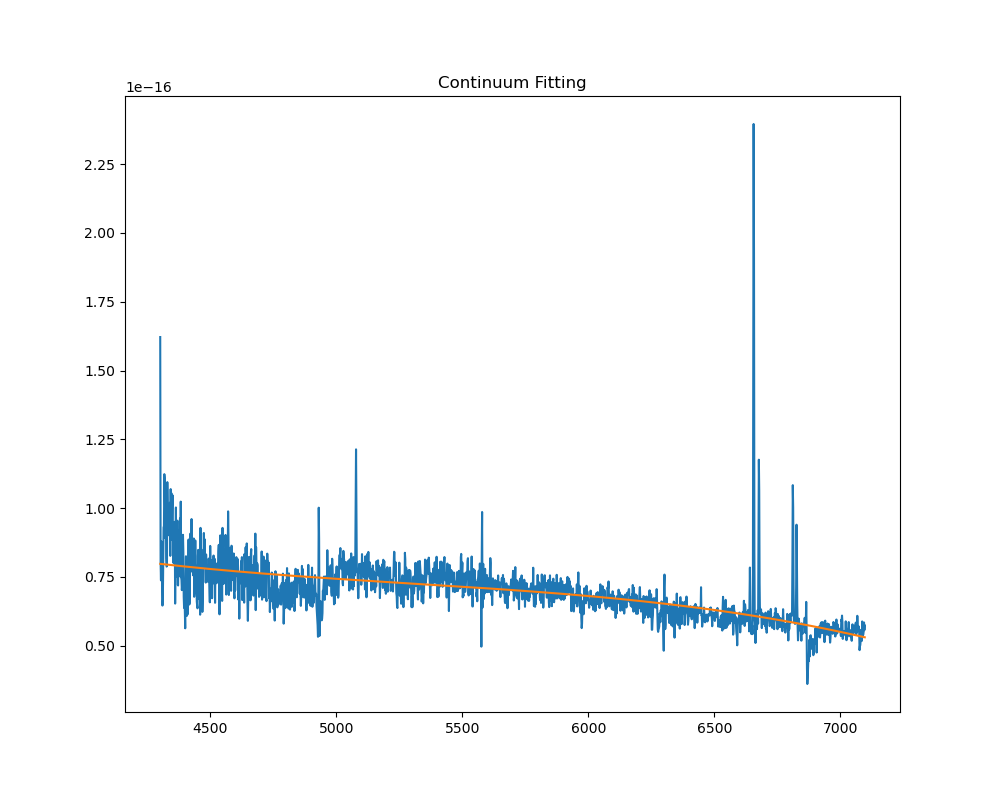

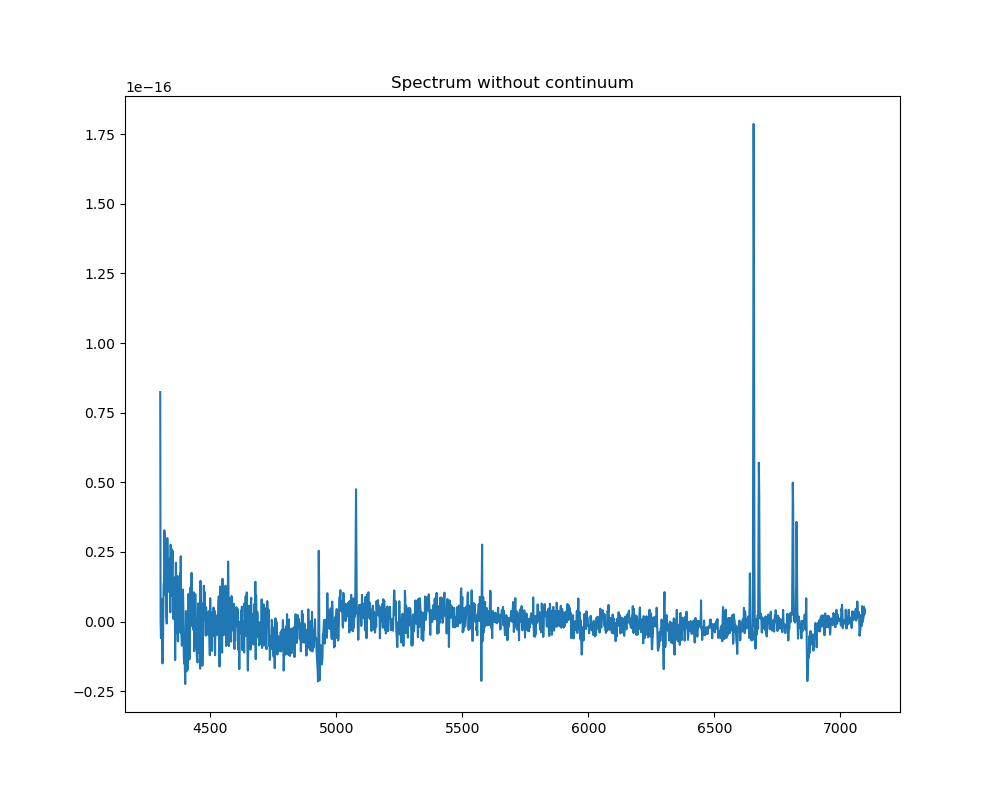

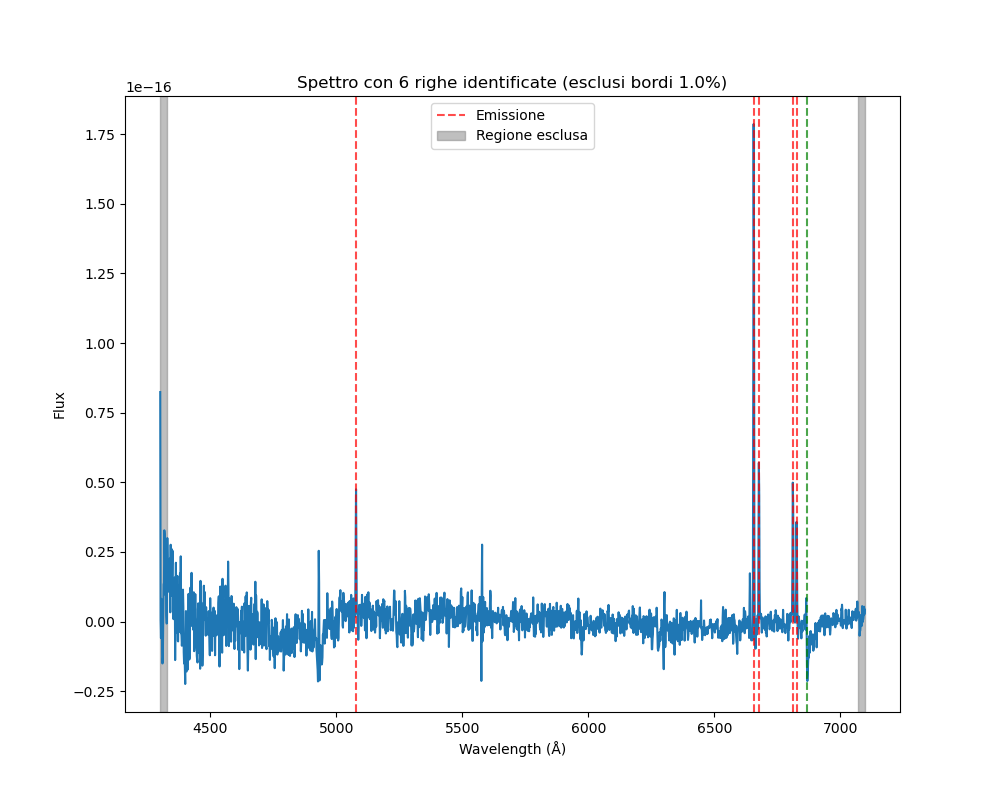

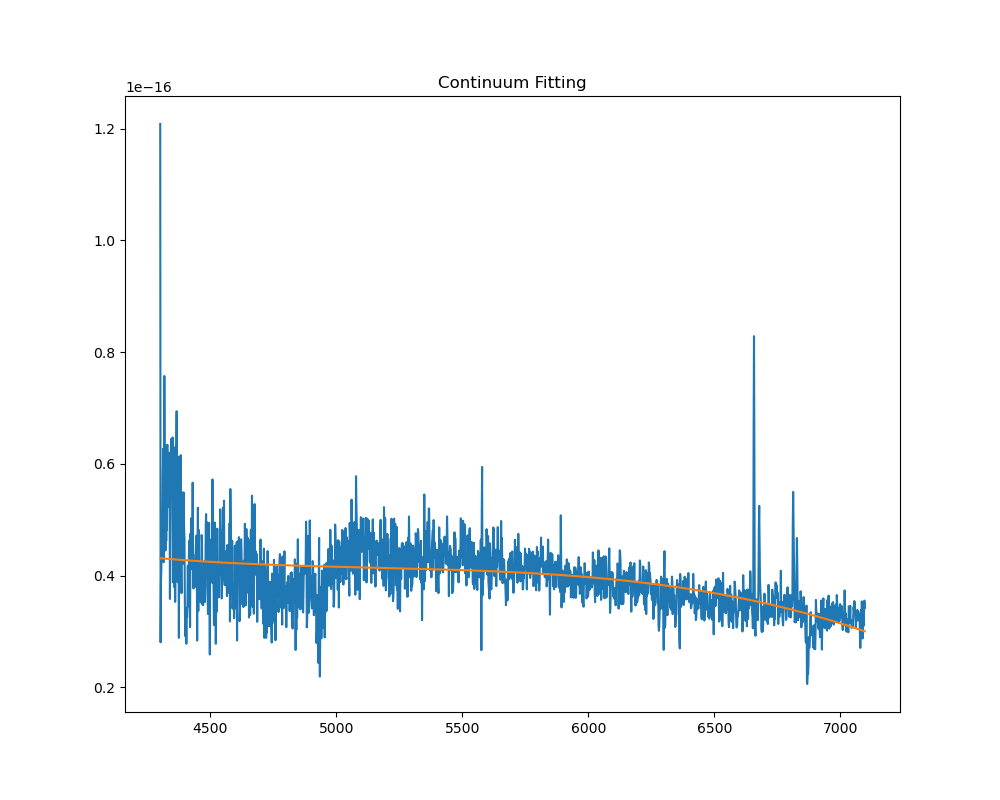

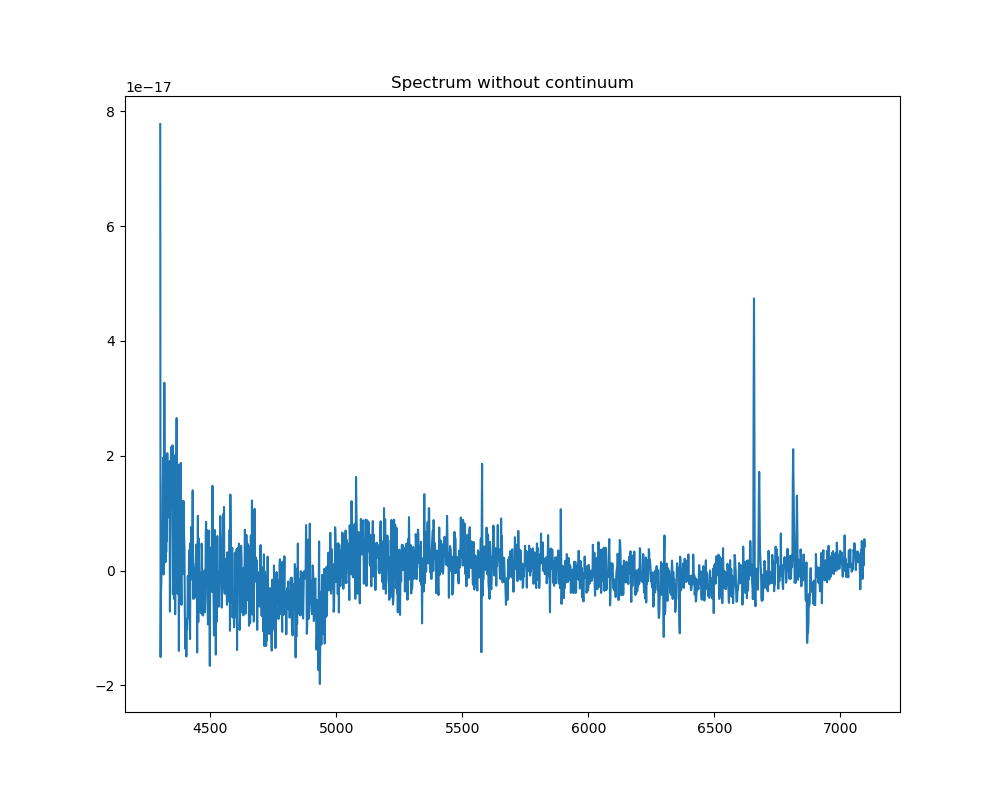

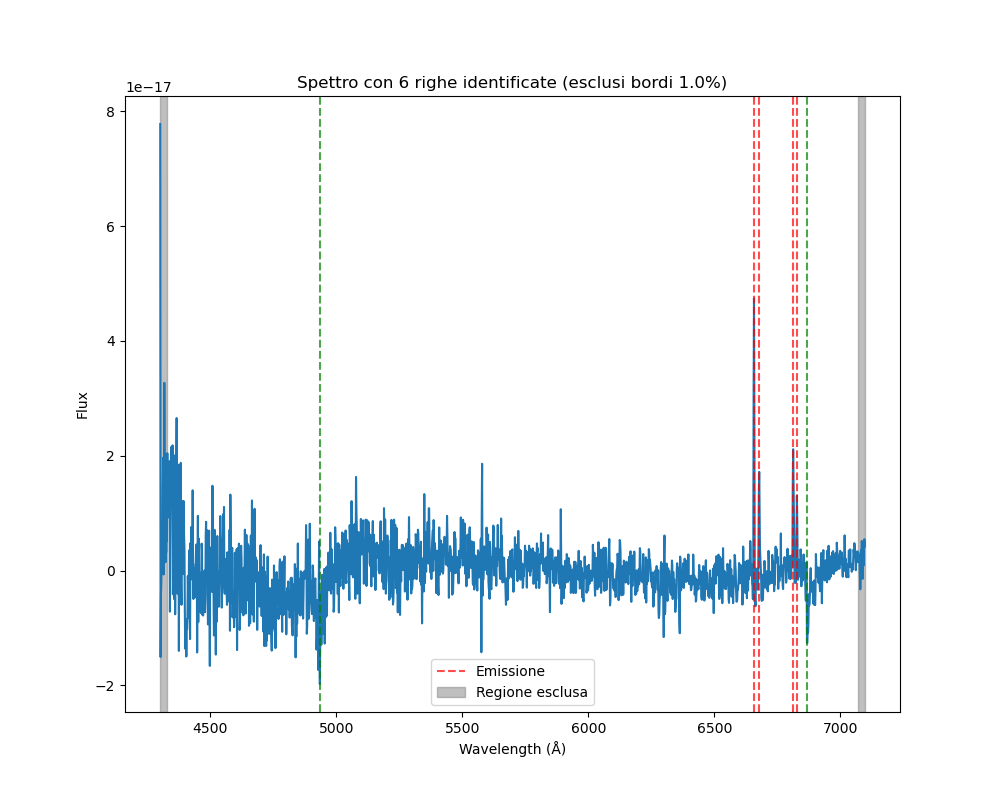

In [48]:
all_lines = []
noise_factor = [7, 8, 8, 5]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale
wv_central = wv[start_idx:end_idx]

for i in range(len(peaks)):
    # Usa tutto lo spettro per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux = spectra_3[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_3[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv * u.Angstrom)
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv * u.Angstrom, spectra_3[i]* 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv * u.Angstrom, flux_continuum_subtracted)
    
    ax2.set_title("Spectrum without continuum")
    
    # Crea lo spettro solo per la regione centrale (senza bordi)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_3[i][start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv[0], wv[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv[end_idx-1], wv[-1], alpha=0.5, color='gray', zorder=1)
    #ax3.axvline(x=wv[start_idx], color='gray', alpha=0.5, linestyle='-', linewidth=2, label='Regione esclusa')
    #ax3.axvline(x=wv[end_idx-1], color='gray', alpha=0.5, linestyle='-', linewidth=2)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [49]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] #2
lines_3 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_4 = [l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = all_lines[1]['line_center']
lines_spectrum_3 = all_lines[2]['line_center']
lines_spectrum_4 = all_lines[3]['line_center']

z_1 = np.zeros(10)
z_2 = np.zeros(10)
z_3 = np.zeros(5)
z_4 = np.zeros(4)

for i in range(10):
    z_1[i] = lines_spectrum_1[i].value / lines_1[i] - 1
    z_2[i] = lines_spectrum_2[i].value / lines_1[i] - 1
z_1_mean = np.mean(z_1)
z_1_std = np.std(z_1)
print(z_1_mean)
print(z_1_std)

z_2_mean = np.mean(z_2)
z_2_std = np.std(z_2)
print(z_2_mean)
print(z_2_std)
    
for i in range(5):
    z_3[i] = lines_spectrum_3[i].value / lines_3[i] - 1
z_3_mean = np.mean(z_3)
z_3_std = np.std(z_3)
print(z_3_mean)
print(z_3_std)

for i in range(4): 
    z_4[i] = lines_spectrum_4[i].value / lines_4[i] - 1
z_4_mean = np.mean(z_4)
z_4_std = np.std(z_4)
print(z_4_mean)
print(z_4_std)

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean]
z_err = [z_1_std, z_2_std, z_3_std, z_4_std]

0.014048451619953762
7.606974805503574e-05
0.014078011418627568
5.732232039905273e-05
0.014069650469979189
7.171644104960647e-05
0.014267512002415661
6.037796073757748e-05


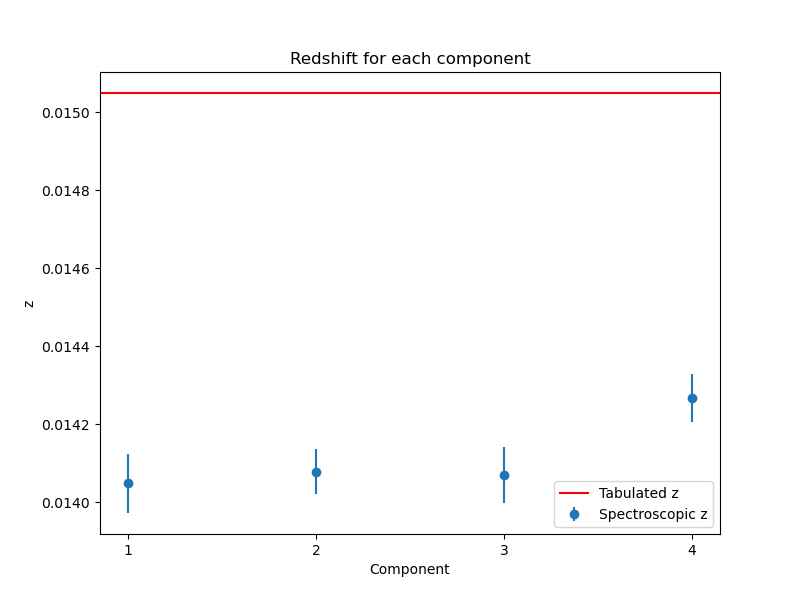

In [50]:
plt.figure(figsize=(8, 6))
comp = [1, 2, 3, 4]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [51]:
def SNR_line(wv, wv_line, spectra, peaks): 
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > wv_line[i]-15)*(wv < wv_line[i]-5) 
        right_region = (wv > wv_line[i]+5)*(wv < wv_line[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > OIII_1[i]-15)*(wv < OIII_1[i]-5) 
        right_region = (wv > OIII_2[i]+5)*(wv < OIII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > SII_1[i]-15)*(wv < SII_1[i]-5) 
        right_region = (wv > SII_2[i]+5)*(wv < SII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > NII_1[i]-15)*(wv < NII_1[i]-5) 
        right_region = (wv > NII_2[i]+5)*(wv < NII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise  

In [52]:
l_Hgam = []
l_HA = []
l_HB = []
l_NII_1 = []
l_NII_2 = []
l_SII_1 = []
l_SII_2 = []
l_OIII_1 = []
l_OIII_2 = []
l_He_1 = []
for i in range(4):
    l_Hgam.append(4340.5*(1+z[i]))
    l_HA.append(6562.8*(1+z[i]))
    l_HB.append(4861.3*(1+z[i]))
    l_NII_1.append(6548.1*(1+z[i]))
    l_NII_2.append(6583.4*(1+z[i]))
    l_SII_1.append(6717.0*(1+z[i]))
    l_SII_2.append(6731.3*(1+z[i]))
    l_OIII_1.append(4958.9*(1+z[i]))
    l_OIII_2.append(5006.8*(1+z[i]))
    l_He_1.append(5875.6*(1+z[i]))

In [53]:
def save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes):
    """
    Generalizza l'analisi SNR per multiple spectra
    
    Parameters:
    - wv: wavelength array
    - l_HB: line parameter
    - spectra_list: lista degli spettri da analizzare
    - peaks: peaks parameter
    - output_dirs: lista delle directory di output
    - file_prefixes: lista dei prefissi per i nomi dei file
    """
    
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, l_HB, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')

def save_snr_OIII(wv, OIII_1, OIII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        
def save_snr_SII(wv, SII_1, SII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')


def save_snr_HA_NII(wv, NII_1, NII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')

In [54]:
spectra_list = [spectra_1, spectra_2, spectra_3]
output_dirs = ['1Sigma', '2Sigma', '3Sigma']
file_prefixes = ['SNR_HB_1s', 'SNR_HB_2s', 'SNR_HB_3s']
save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_1_1s', 'SNR_OIII_1_2s', 'SNR_OIII_1_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_2_1s', 'SNR_OIII_2_2s', 'SNR_OIII_2_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_1_1s', 'SNR_SII_1_2s', 'SNR_SII_1_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_2_1s', 'SNR_SII_2_2s', 'SNR_SII_2_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_1_1s', 'SNR_NII_1_2s', 'SNR_NII_1_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_2_1s', 'SNR_NII_2_2s', 'SNR_NII_2_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HA_1s', 'SNR_HA_2s', 'SNR_HA_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra_list, peaks, output_dirs, file_prefixes)

In [55]:
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_3, peaks)
df = pd.DataFrame({
    '': range(1, len(SNR_HB_1) + 1),  # Colonna indice (1, 2, 3, 4, ...)
    'Component': [f'Component_{i}' for i in range(1, len(SNR_HB_1) + 1)],  # Component_1, Component_2, etc.
    'SNR': SNR_HB_1,
    'Signal': signal_HB_1,
    'Noise': noise_HB_1
})
print(df)

        Component        SNR    Signal     Noise
0  1  Component_1  62.541092  9.056087  0.144802
1  2  Component_2  52.605782  7.052581  0.134065
2  3  Component_3   5.333977  0.810346  0.151922
3  4  Component_4  -0.210839 -0.031216  0.148056


In [56]:
l_HB

[4929.593737860081, 4929.737436909375, 4929.69679182971, 4930.658656097343]

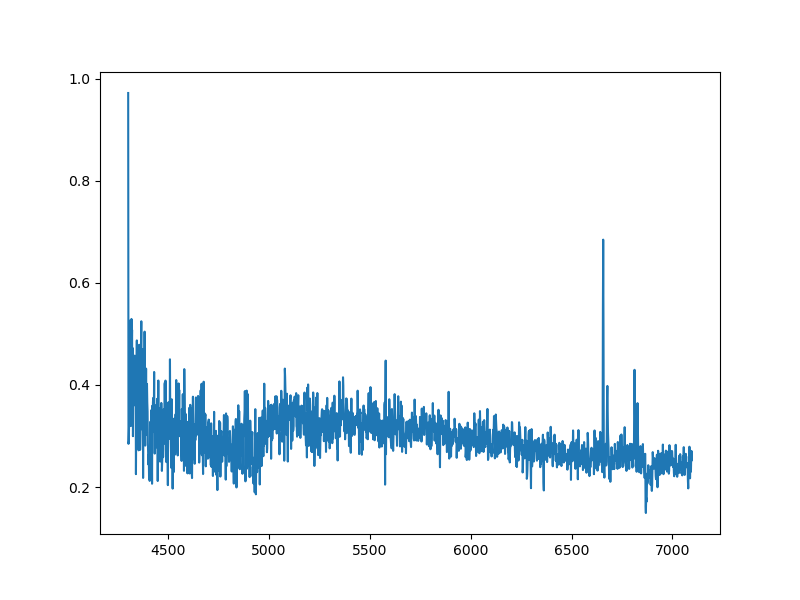

In [58]:
plt.figure(figsize=(8,6))
plt.plot(wv, spectra_2[3])